In [156]:
#python core imports
from urllib.request import urlopen
import json
import numpy as np
import pandas as pd

#geocoding library 
#from geopy.geocoders import Nominatim
#from geopy.extra.rate_limiter import RateLimiter

#visualization imports
import seaborn as sns
from IPython.core.pylabtools import figsize
import matplotlib.pyplot as plt

#python networkx library
import networkx as nx

In [32]:
#create graph object
G = nx.Graph()

#add some nodes
G.add_nodes_from([1, 2, 3, 4, 5])

#add some edges (connections between the nodes) - ie, nodes 1 and 2 are connected, nodes 2 and 3 are connected, etc.
edges=[(1,2), (2,3), (3,1), (1,4), (3,2), (3,5)]
for e in edges:
    G.add_edge(*e, weight=1) #the astrisk "unpacks" the tuple

In [29]:
#view the nodes
G.nodes()

NodeView((1, 2, 3, 4, 5))

In [30]:
#view the edges
G.edges()

EdgeView([(1, 2), (1, 3), (1, 4), (2, 3), (3, 5)])

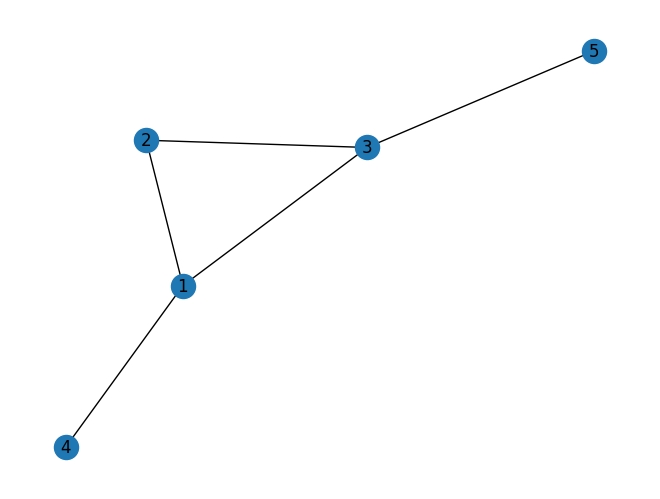

In [31]:
#let's draw the network
nx.draw(G, with_labels=True)
plt.show()

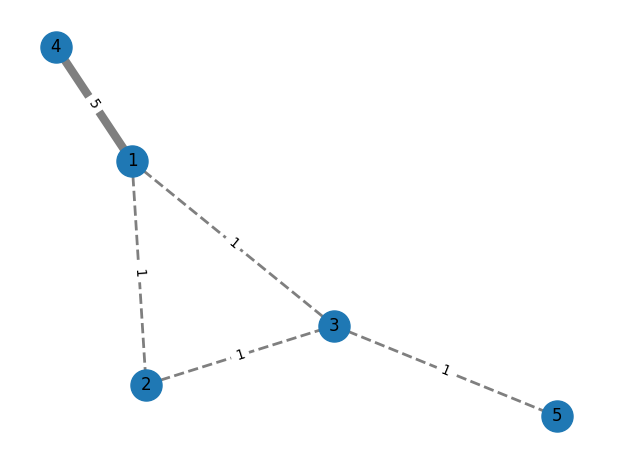

In [52]:
#lets draw it again but add some weights to the edges
G.edges[4,1]['weight']=5

#we'll call any edge with a weight over 1 "large". All the others will be "small"
elarge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] > 1]
esmall = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] <= 1]

# 1. Define the layout (mandatory for placing labels)
pos = nx.spring_layout(G, seed=1)  # positions for all nodes - seed for reproducibility

# nodes
nx.draw_networkx_nodes(G, pos, node_size=500)

# edges - we'll make our "large" edges 6 pixels wide and our "small" edges 2 pixels
nx.draw_networkx_edges(G, pos, edgelist=elarge, alpha=0.5, width=6, style="solid")
nx.draw_networkx_edges(
    G, pos, edgelist=esmall, width=2, alpha=0.5, edge_color="black", style="dashed"
)

# node labels
nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")
# edge weight labels
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels)

ax = plt.gca()
ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.show()

# Real data!

In [135]:
df=pd.read_csv('../data/citibike_032026_sample.csv').sample(frac=0.05)
df

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
5952,47CF9F8674D20772,classic_bike,47:42.2,51:07.1,E 11 St & Ave B,5659.11,E 2 St & Ave A,5553.1,40.727464,-73.979504,40.723077,-73.985836,member
435,5CECCDE21CA327CF,electric_bike,04:12.5,20:53.8,Queens Plaza North & Crescent St,6429.01,Park Ave & E 40 St,6432.15,40.751102,-73.940737,40.751120,-73.978510,member
6755,2618CC1CEFEE31FD,classic_bike,34:41.2,38:44.0,W 22 St & 8 Ave,6224.03,Hudson St & W 13 St,6115.06,40.744751,-73.999154,40.740057,-74.005274,casual
351,7C039A39D1F3FE2E,electric_bike,25:31.5,37:04.7,Mt Morris Park W & W 120 St,7685.14,E 91 St & 2 Ave,7286.01,40.804038,-73.945925,40.781153,-73.949630,casual
2571,1F2DB8C5B1CFA345,classic_bike,52:42.8,55:48.2,College Ave & E 170 St,8175.06,Plaza Dr & W 170 St,8213.01,40.837576,-73.910489,40.840484,-73.917946,member
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3531,896F734074029BED,classic_bike,42:11.1,50:07.1,Frederick Douglass Blvd & W 117 St,7688.12,E 106 St & Madison Ave,7528.31,40.805159,-73.954692,40.793434,-73.949450,member
5259,249EA0BE32679E1D,electric_bike,23:39.3,28:27.3,E 20 St & 2 Ave,5971.08,Ave D & E 12 St,5575.08,40.735877,-73.982050,40.725806,-73.974225,member
1614,0141406FC9A49DE1,classic_bike,29:18.6,44:46.7,31 Ave & 14 St,6966.04,50 St & Northern Blvd,6511.03,40.768200,-73.932266,40.753441,-73.912402,member
1448,91280FFBDE40DD16,electric_bike,18:19.8,22:53.5,E 17 St & Broadway,5980.1,W 25 St & 6 Ave,6215.04,40.737006,-73.990134,40.743954,-73.991449,member


In [136]:
#1. find unique list of start and end stations and store in their own dataframes
df_starts=df[['start_station_name', 'start_lat', 'start_lng']].drop_duplicates()
df_ends=df[['end_station_name', 'end_lat', 'end_lng']].drop_duplicates()

#2. rename columns in both dataframes to make them match
df_starts=df_starts.rename(columns={'start_station_name': 'station_name', 'start_lat': 'station_latitude', 'start_lng': 'station_longitude'})
df_ends=df_ends.rename(columns={'end_station_name': 'station_name', 'end_lat': 'station_latitude', 'end_lng': 'station_longitude'})

#3. concat dataframes - this will be a list of all unique "nodes" in our dataset
df_nodes=pd.concat([df_starts,df_ends]).drop_duplicates().reset_index(drop=True)
df_nodes

,station_name,station_latitude,station_longitude
0,E 11 St & Ave B,40.727464,-73.979504
1,Queens Plaza North & Crescent St,40.751102,-73.940737
2,W 22 St & 8 Ave,40.744751,-73.999154
3,Mt Morris Park W & W 120 St,40.804038,-73.945925
4,College Ave & E 170 St,40.837576,-73.910489
...,...,...,...
627,Metropolitan Ave & Meeker Ave,40.714133,-73.952344
628,Jackson Ave & 49 Ave,40.742930,-73.952037
629,Ave D & E 12 St,40.725806,-73.974225
630,50 St & Northern Blvd,40.753441,-73.912402


In [117]:
df

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
6084,BB18A6FA37A4FC97,electric_bike,48:49.8,59:08.2,Hanson Pl & Ashland Pl,4395.07,Court St & Huntington St,4077.07,40.685068,-73.977908,40.675958,-73.998949,member
2718,99BDE63A0F2612C0,electric_bike,36:20.9,51:40.0,Park Circle & East Dr,3344.02,Park Circle & East Dr,3344.02,40.651566,-73.972212,40.651566,-73.972212,member
7470,7210DAE2047B4A3E,electric_bike,48:16.1,58:14.0,Knickerbocker Ave & Thames St,5018.06,Macon St & Lewis Ave,4310.06,40.705390,-73.929760,40.682820,-73.934880,member
5441,29D771924D87C50F,electric_bike,03:25.5,09:21.2,Melrose Ave & E 150 St,7879.01,Southern Blvd & E 149 St,7788.13,40.816827,-73.917338,40.811892,-73.904192,member
834,1ADDC3E27108081F,electric_bike,28:05.6,45:32.7,Barclay St & Church St,5216.04,8 Ave & W 38 St,6526.05,40.712912,-74.010202,40.754610,-73.991770,member
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9682,B317ED637BEABA77,electric_bike,54:56.8,00:41.0,Ave C & E 16 St,5769.06,E 7 St & Ave C,5545.01,40.729848,-73.974552,40.724129,-73.979013,member
4838,A96DD1DF2420C213,electric_bike,32:49.5,45:19.7,Broadway & W 48 St,6708.04,1 Ave & E 38 St,6230.02,40.760177,-73.984868,40.746202,-73.971822,member
869,7A06E89596BD8083,classic_bike,13:23.6,24:37.9,Broadway & W 37 St,6441.02,W 56 St & 8 Ave,6884.03,40.751726,-73.987535,40.765959,-73.983135,member
7606,46FCB646664A1B5F,classic_bike,40:06.3,09:37.1,Stanton St & Norfolk St,5445.07,Jay St & Tech Pl,4710.06,40.720747,-73.986274,40.695065,-73.987167,member


In [118]:
d_network={'nodes':[],
         'edges':[]}

for index, row in df.iterrows():
    #add nodes
    if row.start_station_name not in d_network['nodes']:
        d_network['nodes'].append(row.start_station_name)
    if row.end_station_name not in d_network['nodes']:
        d_network['nodes'].append(row.end_station_name)

    #add edges - remove edges where start and end are the same station
    if row.start_station_name == row.end_station_name:
        pass
    else:
        d_network['edges'].append((row.start_station_name, row.end_station_name))
        

# New Data Idea - Taxis

In [229]:
#read in the geojson file. We'll name it taxi_zones
with urlopen('https://raw.githubusercontent.com/nickxscott/INFO658/refs/heads/main/notebooks/data/taxi.geojson') as response:
    taxi_zones = json.load(response)

In [230]:
df=pd.read_csv('https://raw.githubusercontent.com/nickxscott/INFO658/refs/heads/main/notebooks/data/taxi_trips_062018.csv')

q99=np.nanquantile(df.trip_distance,0.99)
df_clean=df.loc[(df.trip_distance>0)&(df.trip_distance<=q99)]

q99=np.nanquantile(df.fare_amount,0.99)
df_clean=df_clean.loc[(df_clean.fare_amount>0)&(df.fare_amount<=q99)]

df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,2018 Jun 01 11:45:00 PM,2018 Jun 02 12:02:49 AM,1,1.70,1,N,45,79,1,12.0,0.5,0.5,2.65,0.0,0.3,15.95
1,1,2018 Jun 01 11:45:00 PM,2018 Jun 01 11:58:16 PM,1,2.30,1,N,163,238,1,11.5,0.5,0.5,1.28,0.0,0.3,14.08
2,1,2018 Jun 01 11:45:00 PM,2018 Jun 01 11:56:15 PM,2,0.90,1,N,79,144,2,8.5,0.5,0.5,0.00,0.0,0.3,9.80
3,2,2018 Jun 01 11:44:59 PM,2018 Jun 02 12:02:15 AM,1,4.82,1,N,68,151,1,17.5,0.5,0.5,3.76,0.0,0.3,22.56
4,2,2018 Jun 01 11:44:59 PM,2018 Jun 02 12:12:30 AM,1,11.83,1,N,237,183,2,36.0,0.5,0.5,0.00,0.0,0.3,37.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316240,2,2018 Jun 01 12:00:01 AM,2018 Jun 01 12:04:45 AM,6,1.11,1,N,211,231,2,6.0,0.5,0.5,0.00,0.0,0.3,7.30
316241,1,2018 Jun 01 12:00:00 AM,2018 Jun 01 12:20:14 AM,1,4.10,1,N,79,189,1,16.5,0.5,0.5,5.30,0.0,0.3,23.10
316242,1,2018 Jun 01 12:00:00 AM,2018 Jun 01 12:15:30 AM,1,4.20,1,N,158,238,1,15.0,0.5,0.5,3.25,0.0,0.3,19.55
316243,2,2018 Jun 01 12:00:00 AM,2018 Jun 01 09:42:22 AM,1,1.53,1,N,125,261,1,8.0,0.3,0.5,1.76,0.0,0.0,10.56


In [231]:
zone_dict={}
for zones in taxi_zones['features']:
    zone_id=zones['properties']['locationid']
    zone_name=zones['properties']['zone']
    boro_name=zones['properties']['borough']
    zone_dict[int(zone_id)]={'name':zone_name,
                             'boro':boro_name}

In [232]:
#pu_name=[]
pu_boro=[]
#do_name=[]
do_boro=[]
for index, row in df.iterrows():
    try:
        pu_bor=zone_dict[row.PULocationID]['boro']
        #pu_zone=zone_dict[row.PULocationID]['name']
    except:
        pu_bor='Unknown'
        #pu_zone='Unknown'
   # pu_name.append(pu_zone)
    pu_boro.append(pu_bor)
    try:
        do_bor=zone_dict[row.DOLocationID]['boro']
        #do_zone=zone_dict[row.DOLocationID]['name']
    except:
        do_bor='Unknown'
        #do_zone='Unknown'
    #do_name.append(do_zone)
    do_boro.append(do_bor)

#df['pu_zone_name']=pu_name
df['pu_boro']=pu_boro

#df['do_zone_name']=do_name
df['do_boro']=do_boro

#remove rides with unknown start/end boros
df_clean=df.loc[(df.pu_boro!='Unknown')&(df.do_boro!='Unknown')]

#remove rides starting from staten island and EWR
df_clean=df_clean.loc[(df.pu_boro!='Staten Island') & (df.do_boro!='Staten Island')&(df.pu_boro!='EWR') & (df.do_boro!='EWR')]

In [234]:
df_clean

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,pu_boro,do_boro
0,1,2018 Jun 01 11:45:00 PM,2018 Jun 02 12:02:49 AM,1,1.70,1,N,45,79,1,12.0,0.5,0.5,2.65,0.0,0.3,15.95,Manhattan,Manhattan
1,1,2018 Jun 01 11:45:00 PM,2018 Jun 01 11:58:16 PM,1,2.30,1,N,163,238,1,11.5,0.5,0.5,1.28,0.0,0.3,14.08,Manhattan,Manhattan
2,1,2018 Jun 01 11:45:00 PM,2018 Jun 01 11:56:15 PM,2,0.90,1,N,79,144,2,8.5,0.5,0.5,0.00,0.0,0.3,9.80,Manhattan,Manhattan
3,2,2018 Jun 01 11:44:59 PM,2018 Jun 02 12:02:15 AM,1,4.82,1,N,68,151,1,17.5,0.5,0.5,3.76,0.0,0.3,22.56,Manhattan,Manhattan
4,2,2018 Jun 01 11:44:59 PM,2018 Jun 02 12:12:30 AM,1,11.83,1,N,237,183,2,36.0,0.5,0.5,0.00,0.0,0.3,37.30,Manhattan,Bronx
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316240,2,2018 Jun 01 12:00:01 AM,2018 Jun 01 12:04:45 AM,6,1.11,1,N,211,231,2,6.0,0.5,0.5,0.00,0.0,0.3,7.30,Manhattan,Manhattan
316241,1,2018 Jun 01 12:00:00 AM,2018 Jun 01 12:20:14 AM,1,4.10,1,N,79,189,1,16.5,0.5,0.5,5.30,0.0,0.3,23.10,Manhattan,Brooklyn
316242,1,2018 Jun 01 12:00:00 AM,2018 Jun 01 12:15:30 AM,1,4.20,1,N,158,238,1,15.0,0.5,0.5,3.25,0.0,0.3,19.55,Manhattan,Manhattan
316243,2,2018 Jun 01 12:00:00 AM,2018 Jun 01 09:42:22 AM,1,1.53,1,N,125,261,1,8.0,0.3,0.5,1.76,0.0,0.0,10.56,Manhattan,Manhattan


In [235]:
d_network={'nodes':[],
         'edges':[]}

for index, row in df_clean.iterrows():
    #add nodes
    if row.PULocationID not in d_network['nodes']:
        d_network['nodes'].append(row.PULocationID)
    if row.DOLocationID not in d_network['nodes']:
        d_network['nodes'].append(row.DOLocationID)

    #add edges - remove edges where start and end are the same station
    if row.PULocationID == row.DOLocationID:
        pass
    else:
        d_network['edges'].append((row.PULocationID, row.DOLocationID))

In [236]:
#create list of nodes. In this case, it's a list of every unique station name.
nodes=d_network['nodes']

#add edges, 
edges=d_network['edges']
#for e in edges:
#    G.add_edge(*e, weight=1) #the astrisk "unpacks" the tuple

In [237]:
#create graph object
G = nx.Graph()

#add the nodes and edges to the graph object
G.add_nodes_from(nodes)

for e in edges:
    G.add_edge(*e, weight=1) #the astrisk "unpacks" the tuple

In [238]:
len(d_network['edges'])

292560

In [239]:
#node attributes
for n in G.nodes():
    boro=zone_dict[n]['boro']
    G.nodes[n]['boro']=boro


## Visualizing



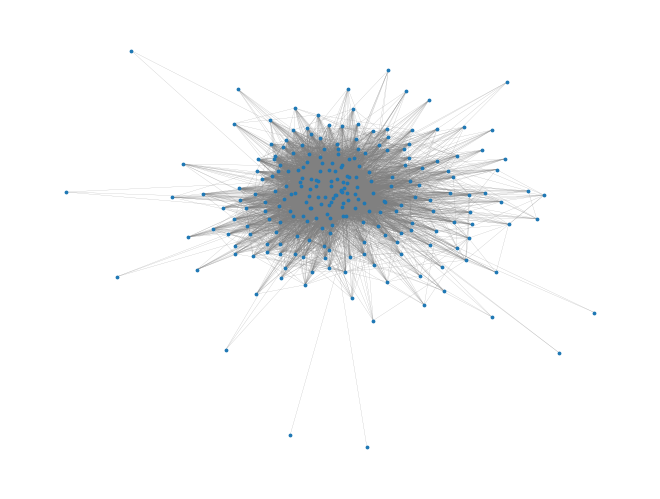

In [241]:
#let's draw the network
nx.draw(G, with_labels=False, node_size=3, width=0.1, edge_color='grey', alpha=1)
plt.show()

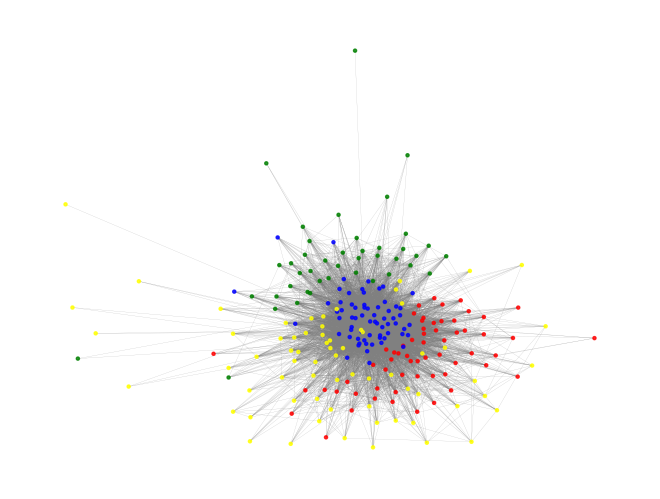

In [242]:
cmap=[]
for n in G.nodes():
    if G.nodes[n]['boro'] == 'Manhattan':
        cmap.append('blue')
    elif G.nodes[n]['boro'] == 'Brooklyn':
        cmap.append('red')
    elif G.nodes[n]['boro'] == 'Queens':
        cmap.append('yellow')
    elif G.nodes[n]['boro'] == 'Bronx':
        cmap.append('green')
    #elif G.nodes[n]['boro'] == 'Staten Island':
    #    cmap.append('orange')
    #elif G.nodes[n]['boro'] == 'EWR':
    #    cmap.append('purple')
        
#let's draw the network
nx.draw(G, with_labels=False, node_size=5, width=0.1, edge_color='grey', node_color=cmap, alpha=0.8)
plt.show()

## Analysis

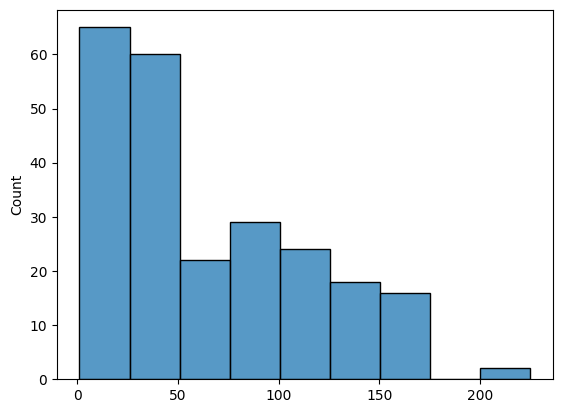

In [244]:
degrees=[]
for n in G.nodes():
    degrees.append(G.degree[n])

len(degrees)

sns.histplot(x=degrees);

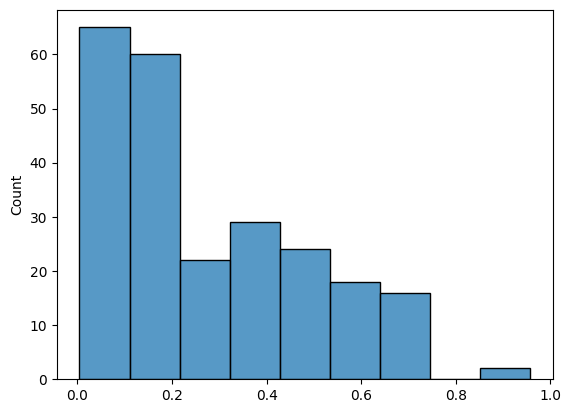

In [247]:
x=list(nx.degree_centrality(G).values())
sns.histplot(x=x);